## 1. Charger et prétraiter le jeu de données MNIST

In [20]:
import tensorflow as tf # Importe la bibliothèque TensorFlow, essentielle pour la construction et l'entraînement de modèles de réseaux de neurones.
from tensorflow import keras # Importe Keras, une API de haut niveau pour construire et entraîner des modèles dans TensorFlow, rendant les choses plus simples.
import matplotlib.pyplot as plt # Importe Matplotlib pour la création de graphiques et de visualisations, utile pour afficher les images et les performances du modèle.
import numpy as np # Importe NumPy, une bibliothèque fondamentale pour le calcul numérique en Python, souvent utilisée pour manipuler des tableaux de données.

### Charger le jeu de données MNIST

In [21]:
# Charge le jeu de données MNIST. Il est divisé en deux parties :
# x_train et y_train: Les images (x_train) et leurs étiquettes (y_train) pour l'entraînement du modèle.
# x_test et y_test: Les images (x_test) et leurs étiquettes (y_test) pour tester la performance du modèle sur des données qu'il n'a jamais vues.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Affiche la forme (dimensions) des ensembles de données pour vérifier leur taille.
# x_train.shape nous dira combien d'images il y a et leurs dimensions (par exemple, 60000 images de 28x28 pixels).
print(f"Forme de l'ensemble d'entraînement: {x_train.shape}")
print(f"Forme de l'ensemble de test: {x_test.shape}")

Forme de l'ensemble d'entraînement: (60000, 28, 28)
Forme de l'ensemble de test: (10000, 28, 28)


### Normaliser les valeurs des pixels

In [22]:
# Normalisation des valeurs des pixels des images.
# Les images MNIST sont en niveaux de gris, avec des valeurs de pixels allant de 0 (noir) à 255 (blanc).
# En divisant par 255.0, nous mettons ces valeurs à l'échelle entre 0 et 1. C'est une étape de prétraitement courante
# qui aide les réseaux de neurones à mieux apprendre et plus rapidement.
x_train = x_train / 255.0
x_test = x_test / 255.0

# Affiche les valeurs maximale et minimale des pixels après la normalisation pour confirmer que l'échelle est bien entre 0 et 1.
print(f"Valeur maximale des pixels après normalisation (entraînement): {x_train.max()}")
print(f"Valeur minimale des pixels après normalisation (entraînement): {x_train.min()}")

Valeur maximale des pixels après normalisation (entraînement): 1.0
Valeur minimale des pixels après normalisation (entraînement): 0.0


### Convertir les étiquettes en format encodé à une seule phase (One-Hot Encoding)

In [23]:
# Conversion des étiquettes numériques en format "One-Hot Encoding".
# Actuellement, les étiquettes (y_train, y_test) sont de simples chiffres (ex: 5 pour le chiffre '5').
# Le One-Hot Encoding transforme un chiffre en un vecteur binaire où seul l'index correspondant au chiffre est à 1 et les autres à 0.
# Par exemple, le chiffre '5' deviendrait [0, 0, 0, 0, 0, 1, 0, 0, 0, 0] pour 10 classes (0-9).
# C'est nécessaire pour la fonction de perte 'categorical_crossentropy' utilisée pour l'entraînement.
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=10)

# Affiche un exemple de la transformation d'une étiquette numérique en format One-Hot.
print(f"Exemple d'étiquette originale: {y_train[0]}")
print(f"Exemple d'étiquette One-Hot: {y_train_one_hot[0]}")

Exemple d'étiquette originale: 5
Exemple d'étiquette One-Hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### Afficher des images d’exemple avec leurs libelles correspondantes

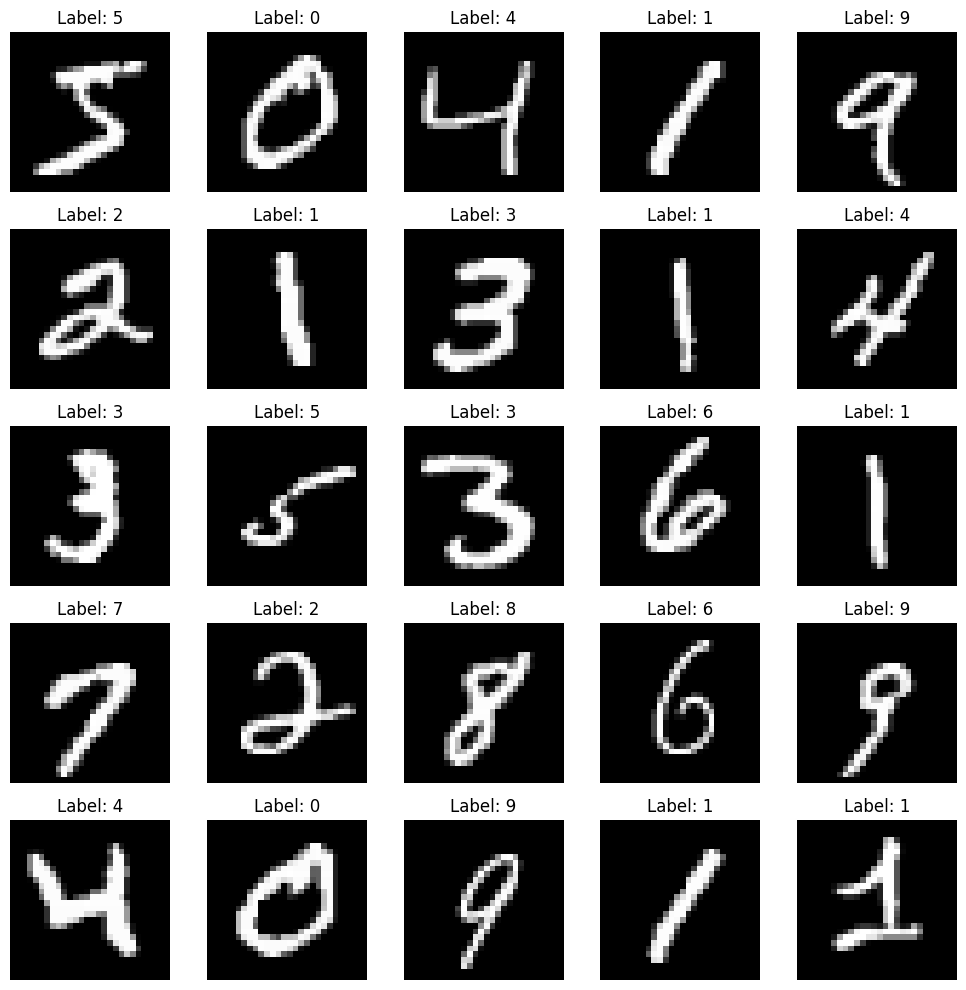

In [12]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

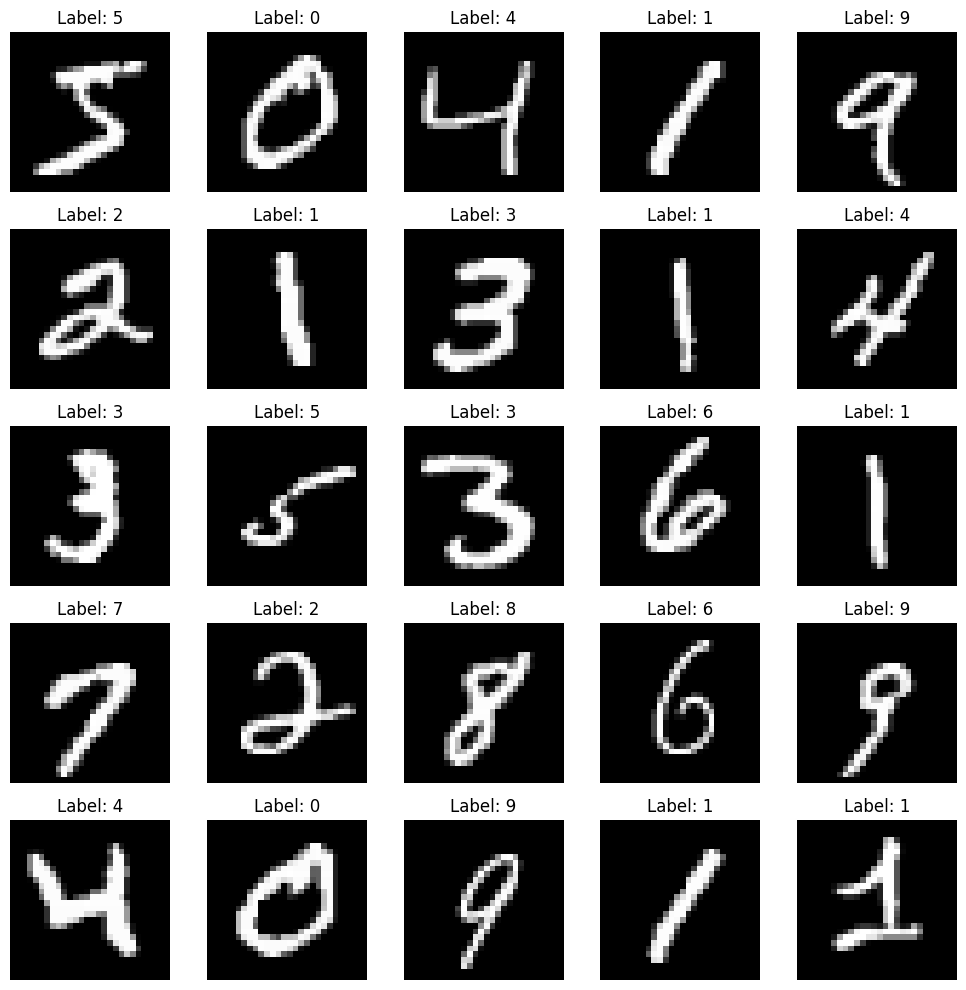

In [24]:
# Crée une figure pour afficher plusieurs images.
plt.figure(figsize=(10, 10))

# Boucle pour afficher les 25 premières images de l'ensemble d'entraînement.
for i in range(25):
    # Crée un sous-graphique dans une grille de 5x5.
    plt.subplot(5, 5, i + 1)
    # Affiche l'image en niveaux de gris (cmap='gray').
    plt.imshow(x_train[i], cmap='gray')
    # Ajoute le label (le vrai chiffre) comme titre pour chaque image.
    plt.title(f"Label: {y_train[i]}")
    # Cache les axes X et Y pour une meilleure visualisation de l'image seule.
    plt.axis('off')
# Ajuste automatiquement les paramètres de la sous-parcelle pour donner un espace serré entre les parcelles.
plt.tight_layout()
# Affiche le graphique avec les images.
plt.show()

## 2. Construire un réseau de neurones entièrement connecté

### Définir le modèle séquentiel

In [13]:
model = keras.Sequential([
    # Première couche: 'Flatten' transforme les images 2D (28x28 pixels) en un vecteur 1D (784 pixels).
    # C'est nécessaire car les couches 'Dense' (entièrement connectées) attendent des entrées 1D.
    keras.layers.Flatten(input_shape=(28, 28)),  # Aplatir les images 28x28 en un vecteur 784

    # Deuxième couche: une couche 'Dense' (entièrement connectée) avec 128 neurones.
    # 'relu' (Rectified Linear Unit) est une fonction d'activation courante qui introduit de la non-linéarité, permettant au réseau d'apprendre des motifs complexes.
    keras.layers.Dense(128, activation='relu'),  # Première couche cachée avec 128 neurones et activation ReLU

    # Troisième couche: une autre couche 'Dense' cachée avec 64 neurones.
    keras.layers.Dense(64, activation='relu'),   # Deuxième couche cachée avec 64 neurones et activation ReLU

    # Dernière couche (couche de sortie): une couche 'Dense' avec 10 neurones (un pour chaque chiffre de 0 à 9).
    # 'softmax' est une fonction d'activation qui convertit les sorties en probabilités. La somme de toutes les probabilités sera égale à 1,
    # et la probabilité la plus élevée indique la prédiction du chiffre par le modèle.
    keras.layers.Dense(10, activation='softmax') # Couche de sortie avec 10 neurones (pour 10 chiffres) et activation Softmax
])

# Affiche un résumé de l'architecture du modèle, y compris le nombre de couches, la forme de sortie et le nombre de paramètres entraînable
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Compiler le modèle

In [14]:
model.compile(
    # 'optimizer': L'algorithme utilisé pour ajuster les poids du réseau pendant l'entraînement.
    # 'adam' est un optimiseur populaire et efficace.
    optimizer='adam',

    # 'loss': La fonction de perte que le modèle essaiera de minimiser.
    # 'categorical_crossentropy' est appropriée pour la classification multi-classes lorsque les étiquettes sont encodées en one-hot.
    loss='categorical_crossentropy',

    # 'metrics': Les métriques à surveiller pendant l'entraînement et l'évaluation.
    # 'accuracy' (précision) mesure la proportion de prédictions correctes.
    metrics=['accuracy']
)

print("Modèle compilé avec succès!")

Modèle compilé avec succès!


## 3. Entraîner le réseau de neurones

### Entraîner le modèle

In [15]:
# Entraîne le modèle en utilisant les données d'entraînement.
# x_train: Les images d'entraînement.
# y_train_one_hot: Les étiquettes d'entraînement (format one-hot).
# epochs: Le nombre de fois que le modèle parcourt l'ensemble de données d'entraînement.
# validation_split: La proportion des données d'entraînement à utiliser comme données de validation
#                   pour surveiller les performances du modèle sur des données non vues pendant l'entraînement principal.
history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=10,
    validation_split=0.2  # Utiliser 20% des données d'entraînement pour la validation
)

print("Entraînement terminé!")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9219 - loss: 0.2671 - val_accuracy: 0.9538 - val_loss: 0.1518
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9664 - loss: 0.1131 - val_accuracy: 0.9697 - val_loss: 0.1061
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9755 - loss: 0.0790 - val_accuracy: 0.9688 - val_loss: 0.1065
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0580 - val_accuracy: 0.9725 - val_loss: 0.0968
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9844 - loss: 0.0469 - val_accuracy: 0.9723 - val_loss: 0.0986
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0379 - val_accuracy: 0.9742 - val_loss: 0.0924
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9904 - loss: 0.0297 - val_accuracy: 0.9640 - val_loss: 0.1521
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9921 - loss: 0.0255 - 

### Observer les tendances de perte et de précision

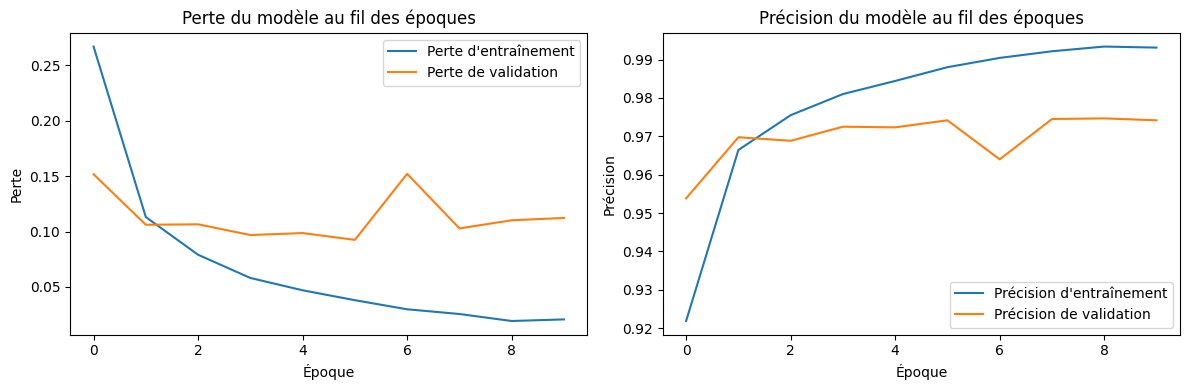

In [16]:
# Crée une figure pour afficher deux graphiques côte à côte
plt.figure(figsize=(12, 4))

# Premier sous-graphique: Perte (Loss) au fil des époques
plt.subplot(1, 2, 1) # (lignes, colonnes, index du graphique)
plt.plot(history.history['loss'], label='Perte d\'entraînement') # Trace la perte sur l'ensemble d'entraînement
plt.plot(history.history['val_loss'], label='Perte de validation') # Trace la perte sur l'ensemble de validation
plt.title('Perte du modèle au fil des époques') # Titre du graphique
plt.xlabel('Époque') # Légende de l'axe X
plt.ylabel('Perte') # Légende de l'axe Y
plt.legend() # Affiche la légende des courbes

# Deuxième sous-graphique: Précision (Accuracy) au fil des époques
plt.subplot(1, 2, 2) # (lignes, colonnes, index du graphique)
plt.plot(history.history['accuracy'], label='Précision d\'entraînement') # Trace la précision sur l'ensemble d'entraînement
plt.plot(history.history['val_accuracy'], label='Précision de validation') # Trace la précision sur l'ensemble de validation
plt.title('Précision du modèle au fil des époques') # Titre du graphique
plt.xlabel('Époque') # Légende de l'axe X
plt.ylabel('Précision') # Légende de l'axe Y
plt.legend() # Affiche la légende des courbes

plt.tight_layout() # Ajuste automatiquement les paramètres du graphique pour qu'il tienne dans la figure
plt.show() # Affiche la figure avec les graphiques

## 4. Évaluer la performance du modèle

### Calculer la précision sur le jeu de données de test

In [17]:
# Évalue la performance finale du modèle sur le jeu de données de test (non vu pendant l'entraînement).
# Retourne la valeur de la fonction de perte et la valeur de la métrique (précision).
loss, accuracy = model.evaluate(x_test, y_test_one_hot)
print(f"Précision du modèle sur le jeu de données de test: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9751 - loss: 0.0985
Précision du modèle sur le jeu de données de test: 0.9751


### Afficher une matrice de confusion

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


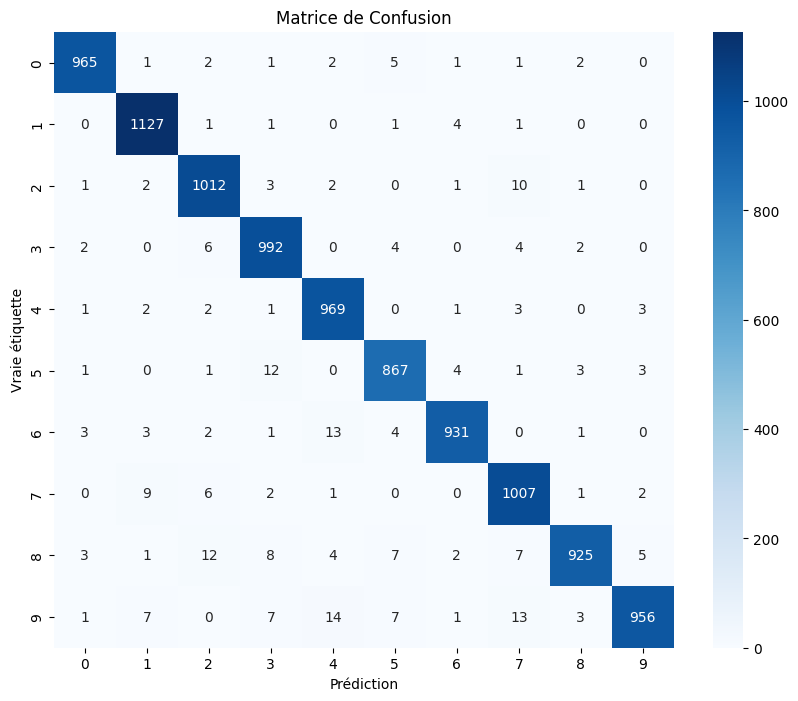

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtenir les prédictions du modèle sur l'ensemble de test.
# model.predict(x_test) renvoie les probabilités pour chaque classe (chiffre 0-9).
# np.argmax() prend l'indice de la probabilité la plus élevée, qui est la prédiction du modèle.
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculer la matrice de confusion.
# Cette matrice compare les vraies étiquettes (y_test) avec les prédictions du modèle (y_pred).
# Chaque ligne représente les instances réelles d'une classe, et chaque colonne représente les instances prédites par le modèle.
conf_mat = confusion_matrix(y_test, y_pred)

# Afficher la matrice de confusion sous forme de heatmap pour une meilleure visualisation.
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues') # annot=True affiche les valeurs, fmt='d' formate en entier
plt.xlabel('Prédiction') # Légende de l'axe X (ce que le modèle a prédit)
plt.ylabel('Vraie étiquette') # Légende de l'axe Y (la valeur réelle)
plt.title('Matrice de Confusion') # Titre du graphique
plt.show()

### Identifier les chiffres avec lesquels le modèle a le plus de difficultés

Le chiffre avec lequel le modèle a le plus de difficultés est le: 9 (nombre d'erreurs: 53)

Quelques exemples de chiffres mal classés:


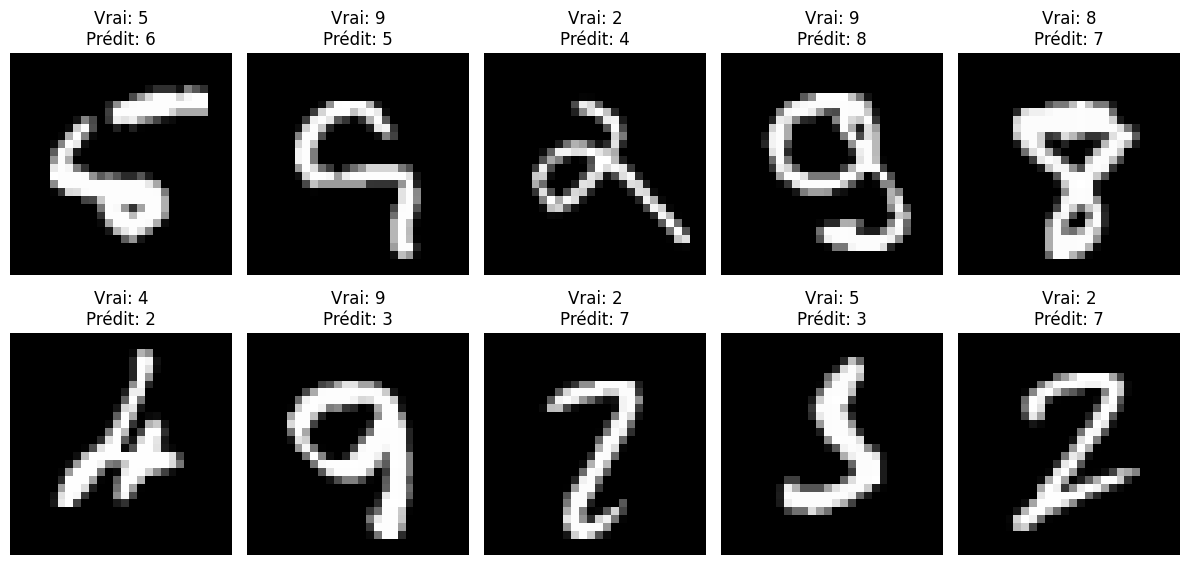

In [19]:
# Initialise une liste pour stocker le nombre de mauvaises classifications pour chaque chiffre (0 à 9).
incorrect_predictions = []
for i in range(10):
    # Compte le nombre d'instances où la vraie étiquette était 'i' MAIS le modèle a prédit quelque chose de différent.
    incorrect_for_digit = np.sum((y_test == i) & (y_pred != i))
    incorrect_predictions.append(incorrect_for_digit)

# Trouve le chiffre pour lequel le nombre de mauvaises classifications est le plus élevé.
most_difficult_digit = np.argmax(incorrect_predictions)

print(f"Le chiffre avec lequel le modèle a le plus de difficultés est le: {most_difficult_digit} (nombre d'erreurs: {incorrect_predictions[most_difficult_digit]})\n")

# Afficher quelques exemples de chiffres mal classés pour comprendre les erreurs du modèle.
print("Quelques exemples de chiffres mal classés:")

plt.figure(figsize=(12, 6))
i = 0 # Compteur pour parcourir les données de test
num_displayed = 0 # Compteur pour le nombre d'images mal classées affichées

# Boucle pour trouver et afficher jusqu'à 10 images mal classées.
while num_displayed < 10 and i < len(x_test):
    # Si la prédiction du modèle (y_pred[i]) est différente de la vraie étiquette (y_test[i]), alors c'est une erreur.
    if y_test[i] != y_pred[i]:
        plt.subplot(2, 5, num_displayed + 1) # Crée un sous-graphique pour l'image
        plt.imshow(x_test[i], cmap='gray') # Affiche l'image en niveaux de gris
        plt.title(f"Vrai: {y_test[i]}\nPrédit: {y_pred[i]}") # Affiche la vraie étiquette et la prédiction
        plt.axis('off') # Cache les axes pour une meilleure visualisation de l'image
        num_displayed += 1 # Incrémente le compteur d'images affichées
    i += 1 # Passe à l'image suivante dans l'ensemble de test
plt.tight_layout() # Ajuste la mise en page pour éviter le chevauchement
plt.show() # Affiche les images